## Part 1: Data Loading and Exploration
Understanding the dataset structure and class distribution

In [1]:
import pandas as pd
import numpy as np

# Load the dataset (TSV format, no headers)
df = pd.read_csv(
    r"C:\AIcybersec\spam.csv.csv",
    sep="\t",
    header=None,
    names=["label", "message"],
    encoding="latin-1"
)

# Basic exploration
print("Dataset shape:", df.shape)
print("\nFirst 5 messages:")
print(df.head())

print("\nClass distribution:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (5572, 2)

First 5 messages:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64
label
ham     0.865937
spam    0.134063
Name: proportion, dtype: float64

Missing values:
label      0
message    0
dtype: int64


## Part 2: Text Preprocessing
Converting text into numerical features using CountVectorizer

In [2]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
# Convert labels to binary (0 = ham, 1 = spam)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
df['message'],
df['label'],
test_size=0.2,
random_state=42,
stratify=df['label'] # Maintain class balance
)
print(f'Training set: {len(X_train)} messages')
print(f'Test set: {len(X_test)} messages')

Training set: 4457 messages
Test set: 1115 messages


In [3]:
# Initialize the vectorizer
vectorizer = CountVectorizer(
lowercase=True, # Convert to lowercase
stop_words='english' # Remove common words like 'the', 'is', 'and'
)
# Fit vectorizer on training data and transform both sets
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)
print(f'Vocabulary size: {len(vectorizer.vocabulary_)} unique words')
print(f'Training matrix shape: {X_train_counts.shape}')
print(f'Test matrix shape: {X_test_counts.shape}')

Vocabulary size: 7434 unique words
Training matrix shape: (4457, 7434)
Test matrix shape: (1115, 7434)


## Part 3: Model Training
Training a Multinomial Naive Bayes classifier

In [4]:
from sklearn.naive_bayes import MultinomialNB
import time
# Initialize and train the classifier
clf = MultinomialNB()
# Measure training time
start_time = time.time()
clf.fit(X_train_counts, y_train)
training_time = time.time() - start_time
print(f'Training completed in {training_time:.4f} seconds')
print('Model is ready to make predictions!')

Training completed in 0.0067 seconds
Model is ready to make predictions!


## Part 4: Model Evaluation
Assessing performance with accuracy, precision, recall, and confusion
matrix

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Make predictions on test set
y_pred = clf.predict(X_test_counts)
# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
print('\n' + '='*60)
# Detailed classification report
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Ham (0)',
'Spam (1)']))
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('\nConfusion Matrix:')
print(cm)

Overall Accuracy: 0.9857 (98.57%)


Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      0.99       966
    Spam (1)       0.97      0.92      0.94       149

    accuracy                           0.99      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115


Confusion Matrix:
[[962   4]
 [ 12 137]]


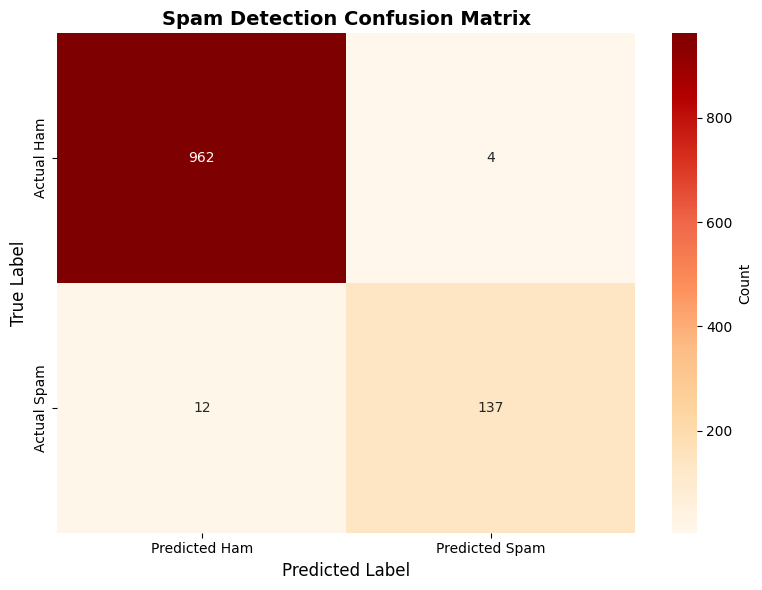

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
# Create heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd',
xticklabels=['Predicted Ham', 'Predicted Spam'],
yticklabels=['Actual Ham', 'Actual Spam'],
cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Spam Detection Confusion Matrix', fontsize=14,
fontweight='bold')
plt.tight_layout()
plt.show()

## Part 5: Testing Custom Messages
Let's see how our model classifies real-world examples

In [13]:
# Test messages
test_messages = [
    "Hey, are we still meeting for lunch tomorrow?",
    "WINNER! You've won a $1000 Walmart gift card. Click here NOW!",
    "Your package will arrive tomorrow between 2-4 PM",
    "Congratulations! You have been selected for a FREE cruise. Call now!",
    "Can you send me the homework assignment from class?"
]

# Vectorize and predict
test_counts = vectorizer.transform(test_messages)
predictions = clf.predict(test_counts)
probabilities = clf.predict_proba(test_counts)

# Display results
print("Custom Message Predictions:")
print("=" * 80)

for i, msg in enumerate(test_messages):
    label = "SPAM" if predictions[i] == 1 else "HAM"
    spam_prob = probabilities[i][1] * 100
    print(f'\nMessage: "{msg}"')
    print(f"Prediction: {label} (Spam probability: {spam_prob:.2f}%)")


Custom Message Predictions:

Message: "Hey, are we still meeting for lunch tomorrow?"
Prediction: HAM (Spam probability: 0.00%)

Message: "WINNER! You've won a $1000 Walmart gift card. Click here NOW!"
Prediction: SPAM (Spam probability: 99.97%)

Message: "Your package will arrive tomorrow between 2-4 PM"
Prediction: HAM (Spam probability: 46.77%)

Message: "Congratulations! You have been selected for a FREE cruise. Call now!"
Prediction: SPAM (Spam probability: 99.78%)

Message: "Can you send me the homework assignment from class?"
Prediction: HAM (Spam probability: 0.94%)


## Part 6: TF-IDF Vectorization
Comparing performance with a more advanced text representation

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(lowercase=True, stop_words='english')

# Transform data



X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train new model
clf_tfidf = MultinomialNB()
clf_tfidf.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

print(f"TF-IDF Accuracy: {accuracy_tfidf:.4f} ({accuracy_tfidf*100:.2f}%)")
print(f"CountVectorizer Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Improvement: {(accuracy_tfidf - accuracy)*100:.2f} percentage points")

# Detailed metrics
print("\nTF-IDF Classification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=['Ham (0)', 'Spam (1)']))


TF-IDF Accuracy: 0.9704 (97.04%)
CountVectorizer Accuracy: 0.9857 (98.57%)
Improvement: -1.52 percentage points

TF-IDF Classification Report:
              precision    recall  f1-score   support

     Ham (0)       0.97      1.00      0.98       966
    Spam (1)       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



Feature Analysis

In [23]:
# Get feature names and their importance
feature_names = vectorizer.get_feature_names_out()
# Get log probabilities for spam class
spam_log_probs = clf.feature_log_prob_[1]
ham_log_probs = clf.feature_log_prob_[0]
# Find top spam indicators
top_spam_indices = spam_log_probs.argsort()[-10:][::-1]
print('Top 10 spam words:', [feature_names[i] for i in
top_spam_indices])

Top 10 spam words: ['free', 'txt', 'ur', 'stop', 'text', 'claim', 'mobile', 'reply', 'www', 'prize']


Comparison between Naive Bayes, Logistic Regression and Random Forest

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Train and compare models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

print("Model Comparison Results")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train_counts, y_train)
    y_pred_model = model.predict(X_test_counts)
    acc = accuracy_score(y_test, y_pred_model)
    print(f"{name}: {acc:.4f} ({acc*100:.2f}%)")


Model Comparison Results
Naive Bayes: 0.9857 (98.57%)
Logistic Regression: 0.9758 (97.58%)
Random Forest: 0.9731 (97.31%)


Cross validation

In [27]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(clf, X_train_counts, y_train, cv=5)
print(f'Cross-validation scores: {scores}')
print(f'Mean accuracy: {scores.mean():.4f} (+/- {scores.std():.4f})')

Cross-validation scores: [0.97421525 0.9809417  0.97867565 0.97643098 0.97755331]
Mean accuracy: 0.9776 (+/- 0.0022)
